In [1]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
plt.rcParams.update({
    'figure.figsize': (3.6, 2.7), 'font.size': 15, 'lines.linewidth': 2,
    'xtick.labelsize': 'small', 'ytick.labelsize': 'small',
    'legend.fontsize': 'small', 'axes.titlesize': 'medium',
    'axes.spines.top': False, 'axes.spines.right': False,
    'image.interpolation': 'nearest', 'savefig.dpi': 100,
})

import os
import pickle
from pathlib import Path
import numpy as np
from jarvis.utils import tqdm

from hexarena import STORE_DIR
FIG_DIR = Path('figures')
os.makedirs(FIG_DIR, exist_ok=True)
rng = np.random.default_rng()

# Construct environment based on belief model

In [2]:
import torch.nn as nn
from jarvis.utils import create_mlp_layers, array2tensor, tensor2array
from jarvis.config import Config

class BeliefModel(nn.Module):
    r"""Class for belief dynamics

    Args
    ----
    n_boxes:
        Number of food boxes.
    encoder:
        Variational encoder that outputs both mean and variance in z-space.
    decoder:
        Decoder that converts samples in z-space to unbounded belief representation.
    
    """

    def __init__(self,
        n_boxes: int = 3,
        z_dim: int = 8,
        encoder: dict|None = None,
        decoder: dict|None = None,
    ):
        super().__init__()
        self.n_boxes = n_boxes
        self.z_dim = z_dim
        self.encoder = nn.Sequential(*create_mlp_layers(
            2*n_boxes+1, 2*z_dim, **Config(encoder),
        ))
        self.decoder = nn.Sequential(*create_mlp_layers(
            z_dim, n_boxes, **Config(decoder),
        ))

        self.rng = np.random.default_rng()

    def encode(self, beliefs, actions):
        inputs = torch.cat([beliefs, nn.functional.one_hot(actions, self.n_boxes+1)], dim=1)
        outs = self.encoder(inputs)
        mus = outs[:, :self.z_dim]
        log_sigmas = outs[:, self.z_dim:]
        return mus, log_sigmas

    def sample(self, mus, log_sigmas, n_scale = 1.):
        ns = torch.tensor(self.rng.normal(loc=0, scale=n_scale, size=mus.shape)).to(mus)
        zs = mus+ns*torch.exp(log_sigmas)
        z_losses = (-0.5*ns.pow(2)-log_sigmas+0.5*zs.pow(2)).sum(dim=1)
        return zs, z_losses

    def decode(self, zs):
        next_beliefs = self.decoder(zs)
        return next_beliefs

    @classmethod
    def get_kl_losses(cls, preds, targets):
        ps = (torch.tanh(targets)+1)/2
        qs = (torch.tanh(preds)+1)/2
        kl_losses = (ps*(torch.log(ps)-torch.log(qs))+(1-ps)*(torch.log(1-ps)-torch.log(1-qs))).sum(dim=1)
        return kl_losses

    def forward(self, beliefs, actions, n_scale = 1.):
        mus, log_sigmas = self.encode(beliefs, actions)
        zs, z_losses = self.sample(mus, log_sigmas, n_scale)
        next_beliefs = self.decode(zs)
        return zs, z_losses, next_beliefs

In [3]:
from gymnasium.spaces import Box, Discrete
import torch
from hexarena.scripts.common import create_env
from gymnasium import Env

class BeliefMDP(Env):

    def __init__(self, model: BeliefModel, reward: float = 10.):
        self.model = model
        self.reward = reward
        self.observation_space = Box(shape=(4,), low=-float('inf'), high=float('inf'))
        self.action_space = Discrete(4)

    def get_observation(self):
        theta = np.arctanh(self.push_cost/self.reward*2-1)
        observation = np.array([theta, *self.belief[0].numpy()])
        return observation

    def reset(self, seed: int|None = None, options: dict|None=None):
        if seed is not None:
            self.model.rng = np.random.default_rng(seed)
        self.belief = torch.tensor(self.model.rng.normal(-1.48, 0.01, (1, 3)), dtype=torch.float)
        if isinstance(options, dict) and 'push_cost' in options:
            assert 0<=options['push_cost']<=self.reward
            self.push_cost = options['push_cost']
        else:
            self.push_cost = self.model.rng.uniform(1e-5, self.reward)
        self.env = create_env(no_arena=True, env_kw={'monkey': {'push_cost': self.push_cost}})
        _, info = self.env.reset(seed=seed)
        return self.get_observation(), info

    def step(self, action: int):
        with torch.no_grad():
            _, _, self.belief = model(self.belief, torch.tensor([action], dtype=torch.long), n_scale=1.)
        _, reward, terminated, truncated, info = self.env.step(action)
        return self.get_observation(), reward, terminated, truncated, info

In [4]:
from stable_baselines3 import PPO
from gymnasium.wrappers import TimeLimit
from irc.utils import ProgressBarCallback

subject_id = 'marco'
model = BeliefModel()
model_pth = STORE_DIR/f'{subject_id}.belief.model.pkl'
if model_pth.exists():
    with open(model_pth, 'rb') as f:
        model.load_state_dict(array2tensor(pickle.load(f)))
        
mdp = BeliefMDP(model)

n_steps = 5000 # time steps per update in PPO
batch_size = 100 # batch size in PPO
algo = PPO(
    policy='MlpPolicy', env=TimeLimit(mdp, 1000),
    n_steps=n_steps, batch_size=batch_size, learning_rate=1e-5,
    gamma=0.99, ent_coef=0.01, device='cpu',
)

subject_id = 'viktor'
policy_pth = STORE_DIR/f'{subject_id}.policy.pkl'
if policy_pth.exists():
    with open(policy_pth, 'rb') as f:
        algo.policy.load_state_dict(array2tensor(pickle.load(f)))
else:
    logs = []
    mdp.reset()
    n_updates = 2000
    algo.policy.set_training_mode(True)
    with tqdm(total=n_updates, unit='update') as pbar:
        pbar_cb = ProgressBarCallback(pbar, disp_freq=n_steps)
        pbar_cb.logs = logs
        algo.env.envs[0].needs_reset = False
        algo.learn(
            total_timesteps=n_updates*n_steps,
            callback=pbar_cb, reset_num_timesteps=False,
        )
    algo.policy.set_training_mode(False)

    with open(policy_pth, 'wb') as f:
        pickle.dump(
            tensor2array(algo.policy.state_dict()), f,
        )

    _, ax = plt.subplots()
    ax.plot(np.arange(1, n_updates/2+1)*n_steps/1000, logs, color='black', linewidth=0.5)
    ax.set_ylim([0, None])
    ax.set_xlabel('# steps (K)')
    ax.set_ylabel('Reward rate')
    plt.show()

In [5]:
push_costs = np.linspace(0.1, 9.9, 40)

rewards_mean = np.zeros((len(push_costs), len(push_costs)))
for i in tqdm(range(len(push_costs)), unit='policy'):
    belief, info = mdp.reset(options={'push_cost': push_costs[i]}) # policy optimal for push_costs[i]
    
    n_steps = 10000
    actions, rewarded, beliefs = [], [], []
    for _ in range(n_steps):
        with torch.no_grad():
            probs = algo.policy.get_distribution(torch.tensor(belief)[None]).distribution.probs[0].numpy()
        action = rng.choice(4, p=probs)
        actions.append(action)
        belief, reward, _, _, info = mdp.step(action)
        beliefs.append(belief)
        rewarded.append(info['obs']['rewarded'])
    actions = np.array(actions)
    beliefs = np.stack(beliefs)
    rewarded = np.array(rewarded).astype(bool)

    for j in range(len(push_costs)):
        rewards_mean[i, j] = rewarded.mean()*10-(actions<3).mean()*push_costs[j]

  0%|                                                                                                         …

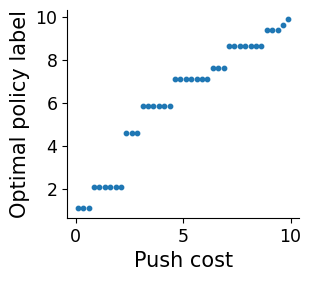

In [6]:
push_costs_optimal = []
for j in range(len(push_costs)):
    i = np.argmax(rewards_mean[:, j])
    push_costs_optimal.append(push_costs[i])
push_costs_optimal = np.array(push_costs_optimal)
_, ax = plt.subplots()
ax.scatter(push_costs, push_costs_optimal, s=10)
ax.set_xlabel('Push cost')
ax.set_ylabel('Optimal policy label')
ax.set_aspect('equal')
plt.show()